# Tutorial 17 - extract_sequence_overview

## Step 0: Setup the project and prepare the data

In [1]:
from pathlib import Path

import pydpeet as eet

We will use "ERROR" as the logging style for better readability of the notebook

In [2]:
eet.set_logging_style("ERROR")

In [3]:
standardized_data = eet.read(
    input_path=str(Path.cwd().parent.parent / "res" / "raw_data_from_cyclers" / "Cal_Ageing_Checkup1.xlsx"),
    config=eet.ReadConfig.Neware_8_0_0_516,
)

In [4]:
segmented_data = eet.add_primitive_segments(df=standardized_data, config=eet.PrimitiveConfig.DEFAULT)

## Step 1: extract_sequence_overview via a SequenceOverviewConfig

In [5]:
config = eet.SequenceOverviewConfig.DEFAULT
config.segment_sequence_config.keys()

dict_keys(['Discharge_iOCV', 'Charge_iOCV', 'CCCV_Charge', 'Pause', 'CC_Charge', 'CV_Charge', 'CP_Charge', 'CC_Discharge', 'CV_Discharge', 'CP_Discharge', 'CRamp_Charge', 'VRamp_Charge', 'PRamp_Charge', 'CRamp_Discharge', 'VRamp_Discharge', 'PRamp_Discharge', 'I', 'V', 'P', 'Charging', 'Discharging'])

In [6]:
eet.extract_sequence_overview(
    df_primitives=segmented_data,
    config=config,
)

,ID,Sequence,Discharge_iOCV,Charge_iOCV,CCCV_Charge,Pause,CC_Charge,CV_Charge,CP_Charge,CC_Discharge,...,VRamp_Charge,PRamp_Charge,CRamp_Discharge,VRamp_Discharge,PRamp_Discharge,I,V,P,Charging,Discharging
0.0,0,1_VRamp_Charge,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
9112.0,1,1_CV_Charge,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,2,0,1,0
11585.0,2,1_CC_Discharge,0,0,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
29405.0,3,1_CV_Discharge,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,3,0,0,2
29915.0,4,2_VRamp_Charge,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,4,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161714.0,488,1_Charge_iOCV,0,1,0,240,0,0,0,0,...,0,0,0,0,0,483,0,0,0,0
162075.0,489,1_Charge_iOCV,0,1,0,0,120,0,0,0,...,0,0,0,0,0,484,0,0,121,0
162174.0,490,1_Charge_iOCV,0,1,0,241,0,0,0,0,...,0,0,0,0,0,485,0,0,0,0
162535.0,491,1_Charge_iOCV,0,1,0,0,121,0,0,0,...,0,0,0,0,0,486,0,0,122,0


## Step 2: use a custom config via sequence_overview_config_wrapper

In [7]:
custom_config = eet.sequence_overview_config_wrapper(
    segment_sequence_config={
        "CC_Discharge": {
            "rules": {
                "variable": "I",
                "type": "Constant",
                "direction": "Discharge",
            }
        },
        "Pause": {
            "rules": {
                "type": "Rest",
            }
        },
        "Discharge_iOCV": {
            "loop": True,
            "min_loops": 2,
            "sequence": ["CC_Discharge", "Pause"],
        },
    },
    show_runtime=True,
)

In [8]:
segments_and_sequences_custom = eet.extract_sequence_overview(
    df_primitives=segmented_data,
    config=custom_config,
)
segments_and_sequences_custom.head(6)

,ID,Sequence,CC_Discharge,Pause,Discharge_iOCV
0.0,0,None,0,0,0
9112.0,1,None,0,0,0
11585.0,2,1_CC_Discharge,1,0,0
29405.0,3,None,0,0,0
29915.0,4,None,0,0,0
29976.0,5,None,0,0,0


## Step 3: Filter the data to matched IDs

array([<Axes: xlabel='Test_Time[s]'>, <Axes: xlabel='Test_Time[s]'>],
      dtype=object)

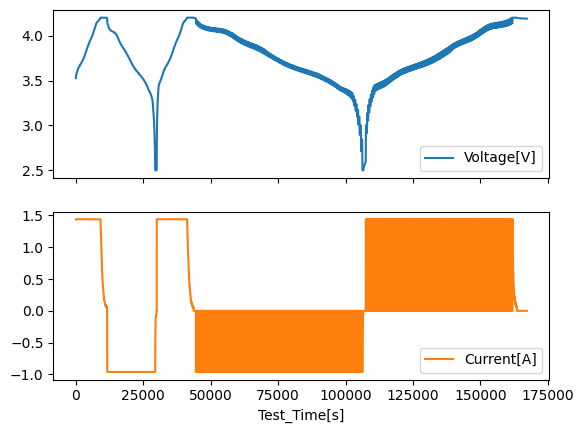

In [9]:
standardized_data.plot(x="Test_Time[s]", y=["Voltage[V]", "Current[A]"], subplots=True)

In [10]:
filtered = segments_and_sequences_custom[segments_and_sequences_custom["Discharge_iOCV"] == 1]
filtered

,ID,Sequence,CC_Discharge,Pause,Discharge_iOCV
44502.0,7,1_Discharge_iOCV,2,0,1
44649.0,8,1_Discharge_iOCV,0,1,1
45010.0,9,1_Discharge_iOCV,3,0,1
45157.0,10,1_Discharge_iOCV,0,2,1
45518.0,11,1_Discharge_iOCV,4,0,1
...,...,...,...,...,...
105101.0,246,1_Discharge_iOCV,0,120,1
105462.0,247,1_Discharge_iOCV,122,0,1
105609.0,248,1_Discharge_iOCV,0,121,1
105970.0,249,1_Discharge_iOCV,123,0,1


array([<Axes: xlabel='Test_Time[s]'>, <Axes: xlabel='Test_Time[s]'>],
      dtype=object)

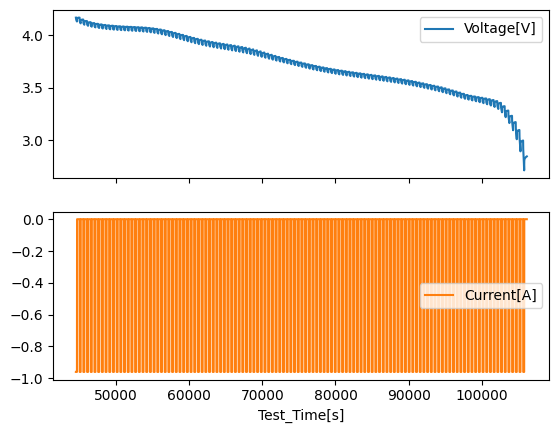

In [11]:
filtered_data = segmented_data[segmented_data["ID"].isin(filtered["ID"])]
filtered_data.plot(x="Test_Time[s]", y=["Voltage[V]", "Current[A]"], subplots=True)